**Implement a linear regression model to predict the prices of houses**
**based on their square footage and the number of bedrooms and bathrooms.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [ ]:
# California Housing Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)


In [ ]:
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [ ]:
#data preprocessing
print("\nDataset Shape : ", df.shape)

print("\nMissing Values :")
print(df.isnull().sum())


Dataset Shape :  (506, 14)

Missing Values :
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [ ]:
# INPUT FEATURES
X = df[['rm', 'lstat', 'ptratio']]

# TARGET
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:


# STEP 6 : CREATE MODEL
model = LinearRegression()

# TRAIN MODEL
model.fit(X_train, y_train)

# STEP 7 : PREDICTION
y_pred = model.predict(X_test)




In [ ]:
# STEP 8 : EVALUATION

print("\nMean Absolute Error :", mean_absolute_error(y_test, y_pred))

print("\nMean Squared Error :", mean_squared_error(y_test, y_pred))

print("\nR2 Score :", r2_score(y_test, y_pred))


Mean Absolute Error : 3.3325380783240957

Mean Squared Error : 27.114957415580577

R2 Score : 0.6302528487272827


In [ ]:
# STEP 9 : MODEL COEFFICIENTS

print("\nIntercept :", model.intercept_)

print("\nCoefficients :")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)



Intercept : 14.58809926157104

Coefficients :
rm : 4.933118359418637
lstat : -0.5671258827383845
ptratio : -0.8670947546233044


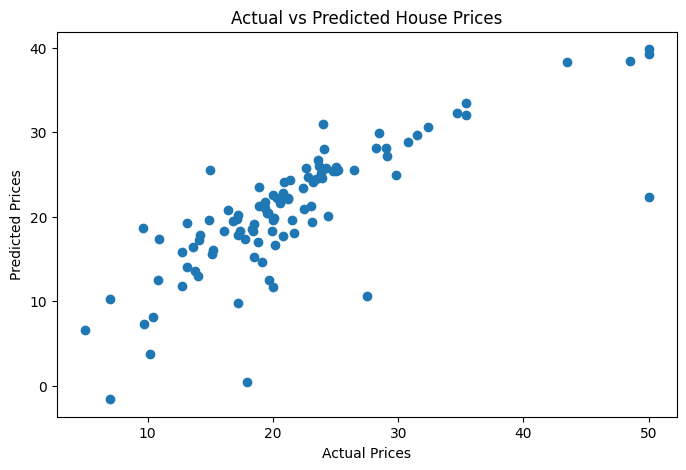

In [ ]:
# STEP 10 : ACTUAL VS PREDICTED GRAPH

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()


In [ ]:
# STEP 11 : PREDICT NEW HOUSE PRICE

# rm = average rooms
# lstat = lower status population %
# ptratio = pupil teacher ratio

new_house = [[6.5, 12.0, 15.0]]

predicted_price = model.predict(new_house)

print("\nPredicted House Price :", predicted_price[0])


Predicted House Price : 26.841436685582003


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:

# STEP 12 : SAVE MODEL

import joblib

joblib.dump(model, "house_price_model.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully
